In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install keras
!pip install tensorflow
!pip install datetime
!pip install seaborn
!pip install ortools

   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   -- ------------------------------------- 0.8/10.8 MB 4.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/10.8 MB 4.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/10.8 MB 5.1 MB/s eta 0:00:02
   ---------------- ----------------------- 4.5/10.8 MB 5.7 MB/s eta 0:00:02
   ----------------------- ---------------- 6.3/10.8 MB 6.4 MB/s eta 0:00:01
   ------------------------------ --------- 8.1/10.8 MB 6.8 MB/s eta 0:00:01
   ------------------------------------ --- 10.0/10.8 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 10.8/10.8 MB 6.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/14.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/14.9 MB 10.0 MB/s eta 0:00:02
   -------- ------------------------------- 3.1/14.9 MB 8.0 MB/s eta 0:00:02
   ----------- ---------------------------- 4.5/14.9 MB 7.1 MB/s eta 0:00:02
   -------

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 5.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
  Using cached urllib3-2.2.3-py3-none-any.whl.metadata (6.5 kB)
INFO: pip is looking at multiple versions of cryptography to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of cryptography to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/276.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/276.5 MB 4.2 MB/s eta 0:01:07
   ---------------------------------------- 1.6/276.5 MB 4.4 MB/s eta 0:01:03
   ---------------------------------------- 

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/18.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/18.0 MB 4.2 MB/s eta 0:00:05
   ----- ---------------------------------- 2.4/18.0 MB 6.7 MB/s eta 0:00:03
   -------- ------------------------------- 3.9/18.0 MB 6.7 MB/s eta 0:00:03
   ------------- -------------------------- 6.0/18.0 MB 7.5 MB/s eta 0:00:02
   ------------------ --------------------- 8.4/18.0 MB 8.3 MB/s eta 0:00:02
   ----------------------- ---------------- 10.7/18.0 MB 8.9 MB/s eta 0:00:01
   ---------------------------- ----------- 12.8/18.0 MB 9.0 MB/s eta 0:00:01
   ---------------------------------- ----- 15.5/18.0 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------  17.8/18.0 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------  17.8/18.0 MB 9.7 MB/s eta 0:00:01
   ---------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.13.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.6 which is incompatible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [39]:
df=pd.read_csv('./okm_augumented_2021.csv')

In [4]:
df.head()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


In [5]:
#구조 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


In [6]:
#결측치 수 확인
df.isnull().sum()

날짜           0
시간           0
15분          0
30분          0
45분          0
60분          0
평균           0
생산량          0
기온           0
풍속           3
습도           0
강수량          1
전기요금(계절)     0
day          0
d            0
m            0
공장인원        17
인건비          0
dtype: int64

In [40]:
#결측치 0 채우기
df['강수량'].fillna(0, inplace=True)
df

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


In [41]:
#전체 변수 결측치 값 채우기
df.fillna(0, inplace=True)
df_frame=df

In [9]:
df.isnull().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

In [10]:
#요약통계량 확인
df.describe()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
count,6.168000e+03,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000
mean,2.021049e+07,12.428016,90.410182,92.695363,95.106355,95.037938,93.424125,467.344682,15.906064,2.062630,70.098735,2.243888,162.757198,4.003891,15.256809,4.770428,0.898851,1.313959
std,2.447756e+02,12.847309,55.349403,57.942122,59.285709,59.347554,57.355938,857.571815,9.160356,1.164724,22.996164,9.612754,30.820855,2.006957,8.799601,2.452431,1.983335,0.241700
min,2.021010e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-12.000000,0.000000,8.000000,0.000000,109.800000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,2.021031e+07,6.000000,23.000000,23.000000,23.000000,23.000000,23.000000,0.000000,9.600000,1.200000,53.000000,0.000000,167.200000,2.000000,8.000000,3.000000,0.000000,1.000000
50%,2.021051e+07,12.000000,101.000000,104.000000,105.000000,107.000000,104.000000,45.000000,17.400000,1.900000,74.000000,0.000000,167.200000,4.000000,15.000000,5.000000,0.111111,1.500000
75%,2.021071e+07,18.000000,133.000000,143.000000,149.000000,149.000000,144.000000,637.250000,23.300000,2.800000,91.000000,0.100000,191.600000,6.000000,23.000000,7.000000,1.160310,1.500000
max,2.021091e+07,188.000000,207.000000,222.000000,218.000000,214.000000,208.000000,9830.000000,33.400000,7.600000,98.000000,122.400000,191.600000,7.000000,31.000000,9.000000,48.386364,1.500000


In [11]:
#상관관계 파악
df.corr()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
날짜,1.000000,0.065435,0.035555,0.034746,0.037285,0.036244,0.036572,0.070719,0.863028,-0.268152,0.548722,0.160855,0.835836,-0.011838,-0.035210,0.999357,-0.002136,0.005469
시간,0.065435,1.000000,0.130084,0.124554,0.115947,0.097021,0.117865,0.031816,0.150262,0.009283,-0.030201,0.049157,0.067609,-0.036188,-0.010330,0.065681,0.012563,-0.034275
15분,0.035555,0.130084,1.000000,0.980295,0.966859,0.950034,0.984688,0.520424,0.050760,0.115215,-0.085205,-0.008241,0.055881,-0.428312,0.052554,0.033601,0.295909,-0.202557
30분,0.034746,0.124554,0.980295,1.000000,0.982443,0.959004,0.991255,0.515841,0.049524,0.114173,-0.084102,-0.010410,0.056203,-0.426674,0.055754,0.032679,0.288622,-0.195760
45분,0.037285,0.115947,0.966859,0.982443,1.000000,0.984789,0.994774,0.513789,0.052818,0.115768,-0.082522,-0.013136,0.059044,-0.432957,0.056047,0.035203,0.286091,-0.211635
60분,0.036244,0.097021,0.950034,0.959004,0.984789,1.000000,0.984828,0.499723,0.055651,0.128605,-0.090875,-0.014812,0.057878,-0.437576,0.056354,0.034153,0.276778,-0.243434
평균,0.036572,0.117865,0.984688,0.991255,0.994774,0.984828,1.000000,0.517948,0.052996,0.119837,-0.086508,-0.011759,0.058096,-0.436280,0.055824,0.034499,0.289860,-0.215982
생산량,0.070719,0.031816,0.520424,0.515841,0.513789,0.499723,0.517948,1.000000,0.117780,0.115691,-0.109503,0.008171,0.068930,-0.259129,0.044836,0.068976,0.785115,-0.280625
기온,0.863028,0.150262,0.050760,0.049524,0.052818,0.055651,0.052996,0.117780,1.000000,-0.192121,0.401553,0.118524,0.809825,0.010130,0.108487,0.857490,0.030540,-0.184611
풍속,-0.268152,0.009283,0.115215,0.114173,0.115768,0.128605,0.119837,0.115691,-0.192121,1.000000,-0.440112,0.048412,-0.254750,0.004037,-0.010588,-0.267261,0.088944,-0.350115


<Axes: >

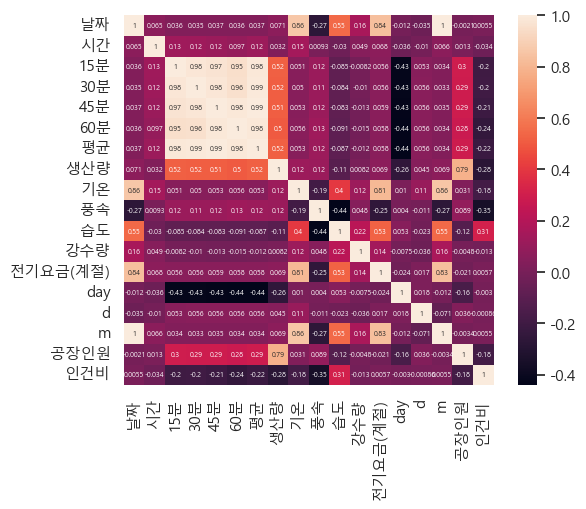

In [12]:
#상관관계 시각화
plt.rc('font', family='Malgun Gothic')
sns.set(font='Malgun Gothic',
        rc={'axes.unicode_minus': False},
        style='darkgrid')

sns.heatmap(df.corr(), vmax=1, square=True, annot=True, annot_kws={'size': 5})

In [13]:
df=df.drop(columns=["생산량","기온","풍속","습도","강수량","전기요금(계절)","day","d","m","공장인원","인건비"])
df

,날짜,시간,15분,30분,45분,60분,평균
0,20210101,0,62,61,61,61,61
1,20210101,1,96,93,116,113,105
2,20210101,2,106,96,106,107,104
3,20210101,3,92,110,110,109,105
4,20210101,4,108,105,106,108,107
...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153
6164,20210914,20,124,130,128,130,128
6165,20210914,21,134,130,125,124,128
6166,20210914,22,100,109,120,114,111


In [14]:
df = df.rename(columns={
    '15분': 'Peak Consumption in 15 minute',
    '30분': 'Peak Consumption in 30 minute',
    '45분': 'Peak Consumption in 45 minute',
    '60분': 'Peak Consumption in 60 minute',
    '평균': 'Average Peak Consumption in 1 hour'
})
df

,날짜,시간,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
0,20210101,0,62,61,61,61,61
1,20210101,1,96,93,116,113,105
2,20210101,2,106,96,106,107,104
3,20210101,3,92,110,110,109,105
4,20210101,4,108,105,106,108,107
...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153
6164,20210914,20,124,130,128,130,128
6165,20210914,21,134,130,125,124,128
6166,20210914,22,100,109,120,114,111


In [15]:
#1시간 단위로 인덱스 생성
index_column = pd.date_range(start='2021-01-01 00:00', end='2021-09-14 23:00', freq='H')
index_column

DatetimeIndex(['2021-01-01 00:00:00', '2021-01-01 01:00:00',
               '2021-01-01 02:00:00', '2021-01-01 03:00:00',
               '2021-01-01 04:00:00', '2021-01-01 05:00:00',
               '2021-01-01 06:00:00', '2021-01-01 07:00:00',
               '2021-01-01 08:00:00', '2021-01-01 09:00:00',
               ...
               '2021-09-14 14:00:00', '2021-09-14 15:00:00',
               '2021-09-14 16:00:00', '2021-09-14 17:00:00',
               '2021-09-14 18:00:00', '2021-09-14 19:00:00',
               '2021-09-14 20:00:00', '2021-09-14 21:00:00',
               '2021-09-14 22:00:00', '2021-09-14 23:00:00'],
              dtype='datetime64[ns]', length=6168, freq='H')

In [17]:
df.index=index_column
df.index.names=['Date']
df.head()

,날짜,시간,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61
2021-01-01 01:00:00,20210101,1,96,93,116,113,105
2021-01-01 02:00:00,20210101,2,106,96,106,107,104
2021-01-01 03:00:00,20210101,3,92,110,110,109,105
2021-01-01 04:00:00,20210101,4,108,105,106,108,107


In [18]:
df=df.drop(columns=['날짜','시간'])
df

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62,61,61,61,61
2021-01-01 01:00:00,96,93,116,113,105
2021-01-01 02:00:00,106,96,106,107,104
2021-01-01 03:00:00,92,110,110,109,105
2021-01-01 04:00:00,108,105,106,108,107
...,...,...,...,...,...
2021-09-14 19:00:00,152,151,171,139,153
2021-09-14 20:00:00,124,130,128,130,128
2021-09-14 21:00:00,134,130,125,124,128


In [19]:
#데이터 실수형으로 변경
df['Peak Consumption in 15 minute'] = [float(str(val).replace(',', '').replace(',', '')) for val in df['Peak Consumption in 15 minute'].values]
df['Peak Consumption in 30 minute'] = [float(str(val).replace(',', '').replace(',', '')) for val in df['Peak Consumption in 30 minute'].values]
df['Peak Consumption in 45 minute'] = [float(str(val).replace(',', '').replace(',', '')) for val in df['Peak Consumption in 45 minute'].values]
df['Peak Consumption in 60 minute'] = [float(str(val).replace(',', '').replace(',', '')) for val in df['Peak Consumption in 60 minute'].values]
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107


In [20]:
#크기 지정
sns.set(rc={"figure.figsize":(20,10)})

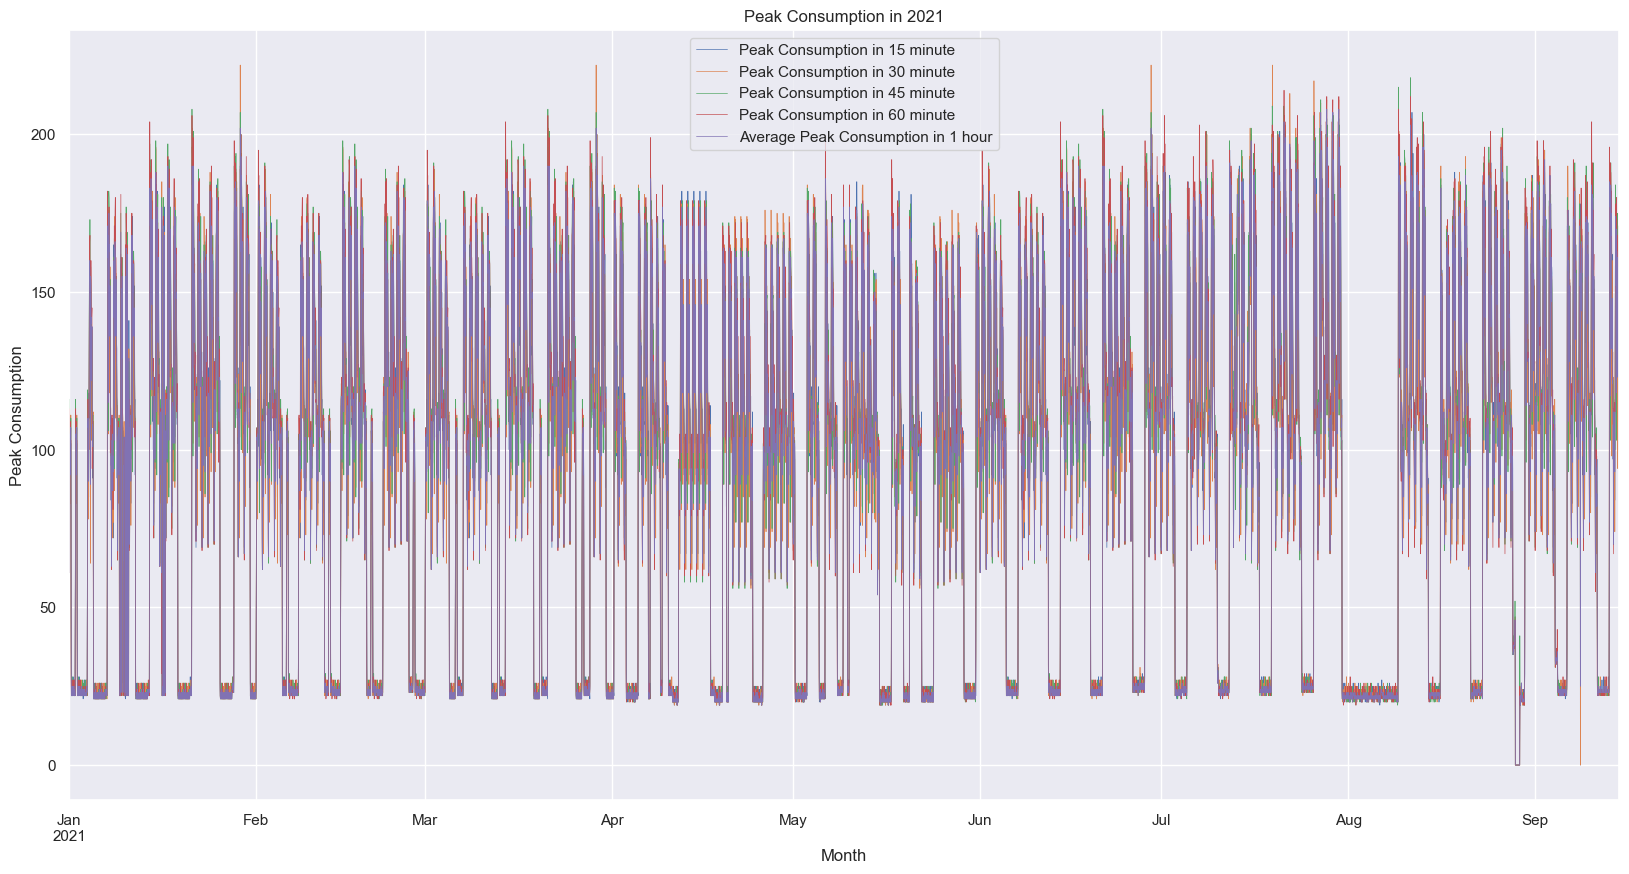

In [25]:
#2021년 최대수요전력값 시각화
df[['Peak Consumption in 15 minute',
    'Peak Consumption in 30 minute',
    'Peak Consumption in 45 minute',
    'Peak Consumption in 60 minute',
    'Average Peak Consumption in 1 hour']].plot(linewidth=0.5)

plt.title('Peak Consumption in 2021')
plt.xlabel('Month')
plt.ylabel('Peak Consumption')
plt.show()

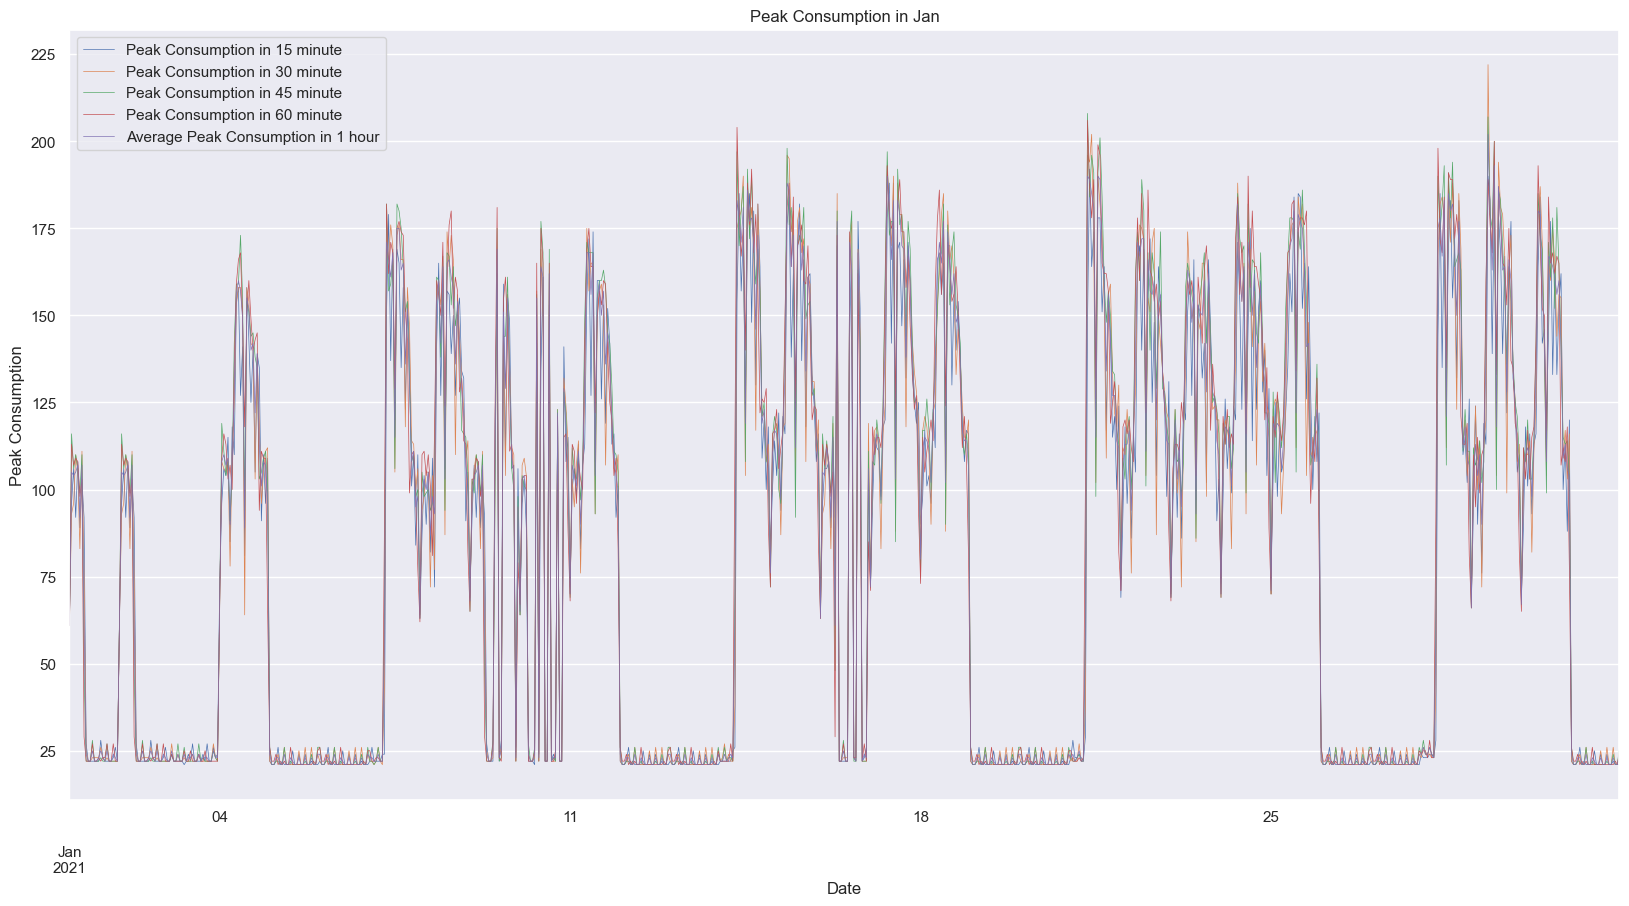

In [26]:
#2021년 1월 최대수요전력값 시각화
#loc: 인덱스를 기준으로 원하는 데이터를 선택
df.loc['2021-01'].plot(linewidth=0.5)

plt.title('Peak Consumption in Jan')
plt.ylabel('Peak Consumption')
plt.show()

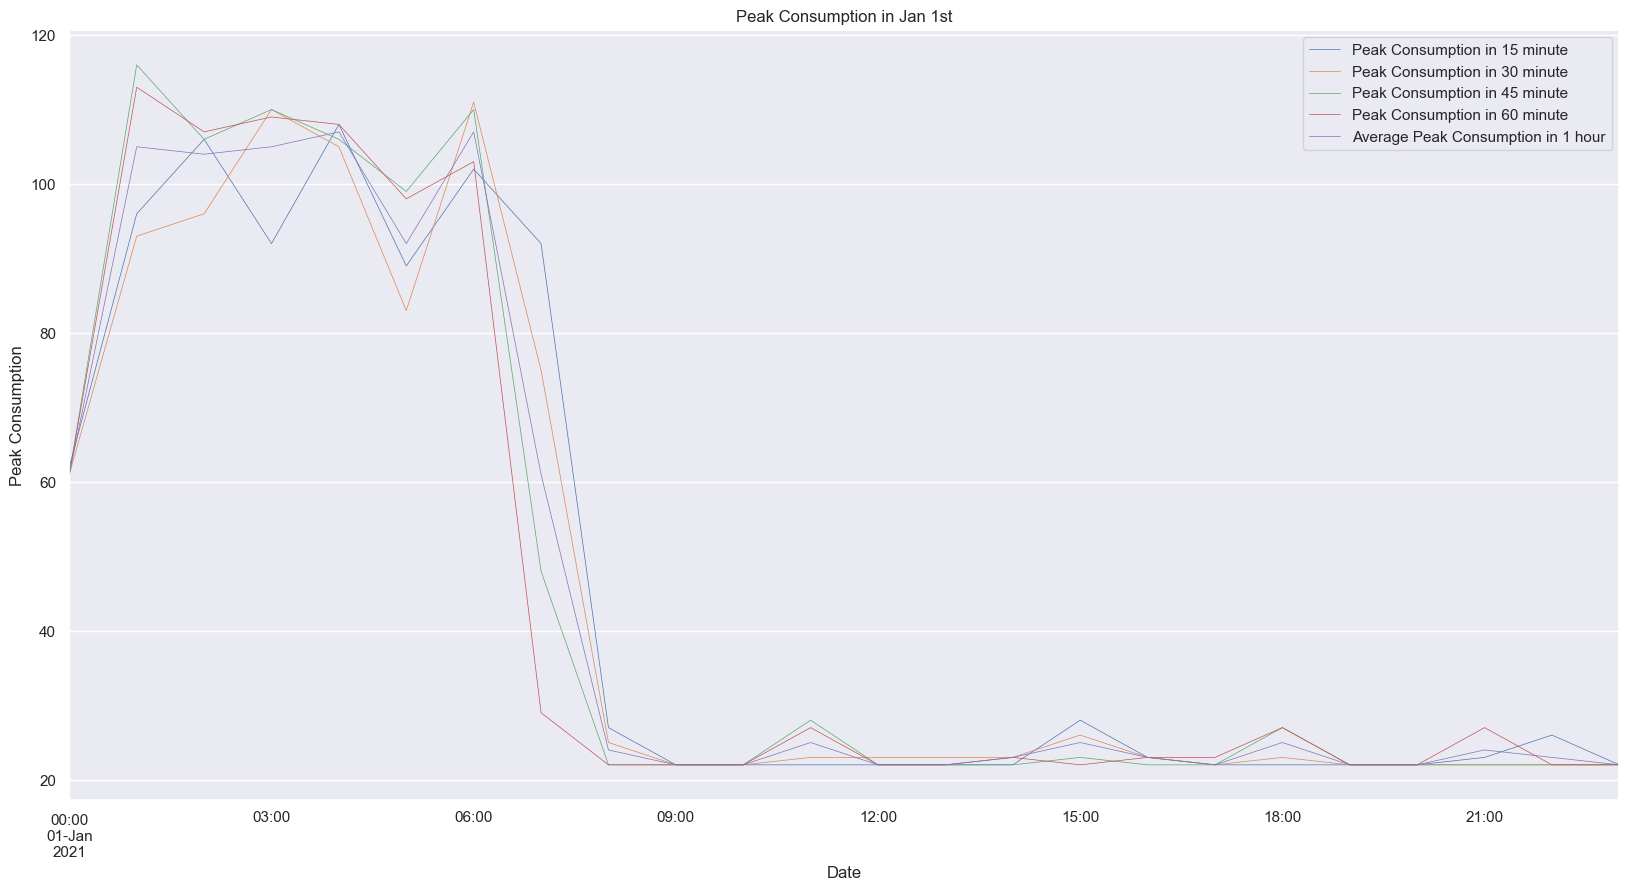

In [27]:
#2021년 1월 1일 최대수요전력값 시각화
df.loc['2021-01-01'].plot(linewidth=0.5)

plt.title('Peak Consumption in Jan 1st')
plt.ylabel('Peak Consumption')
plt.show()

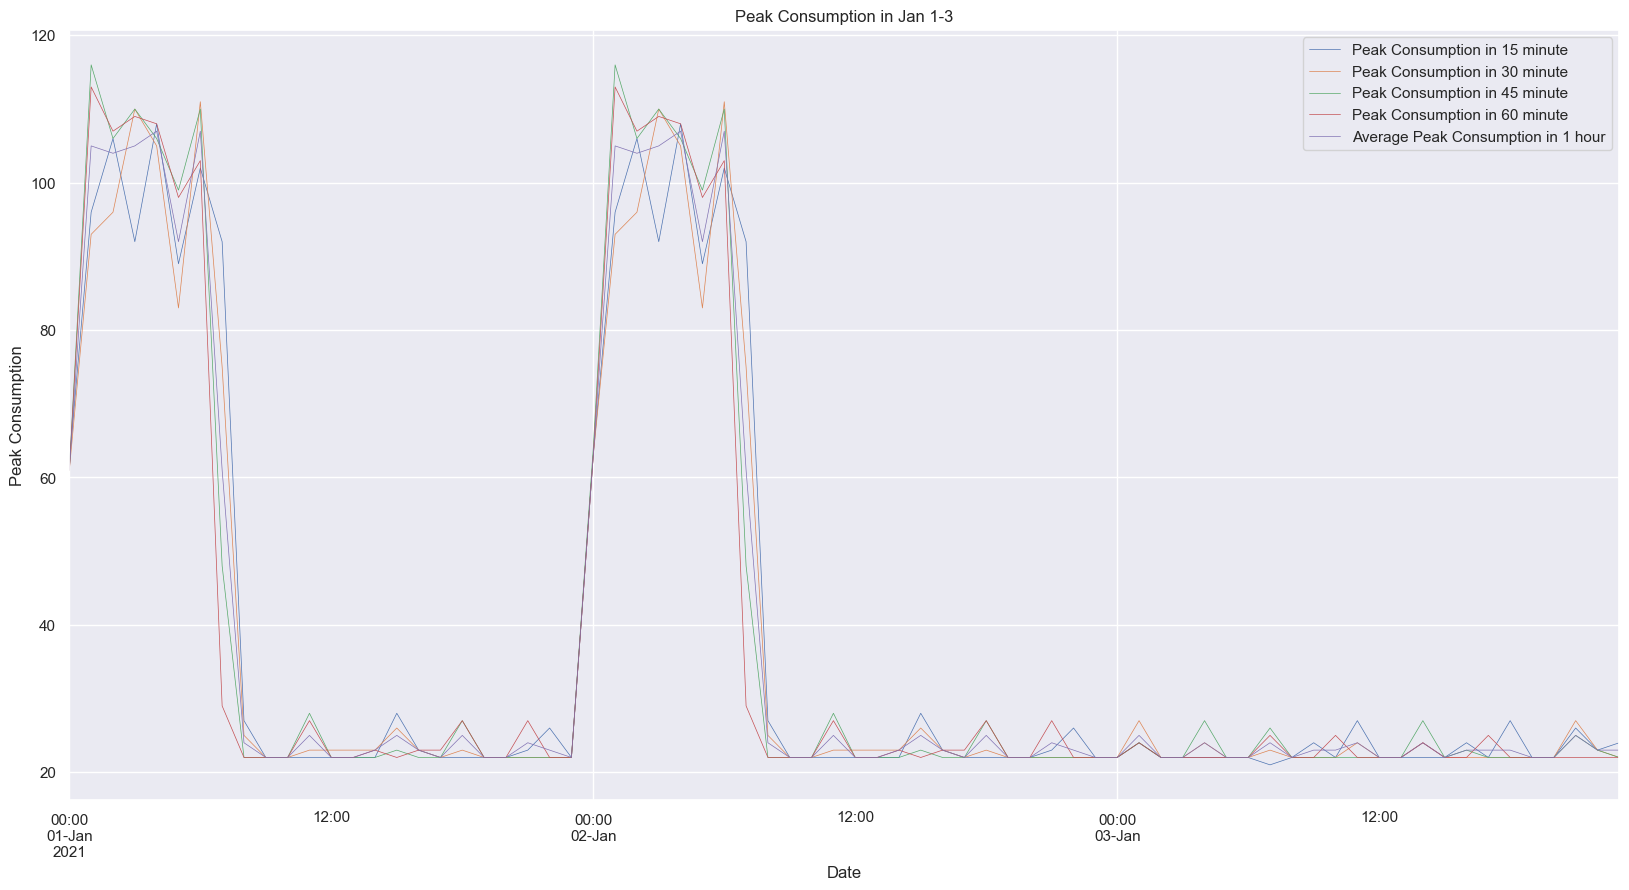

In [28]:
#2021년 1월 1일부터 3일까지 최대수요전력값 시각화
df.loc['2021-01-01':'2021-01-03'].plot(linewidth=0.5)

plt.title('Peak Consumption in Jan 1-3')
plt.ylabel('Peak Consumption')
plt.show()

In [29]:
#변수 추가
df['Vacation'] = np.zeros(len(df))
df['Weekend'] = np.zeros(len(df))
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61,0.0,0.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105,0.0,0.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104,0.0,0.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105,0.0,0.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107,0.0,0.0


In [31]:
#요일값 확인
df.loc['2021-01-01'].index.dayofweek
#4는 금요일, 24개는 24시간 

Index([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype='int32', name='Date')

In [43]:
df.loc[(df.index.dayofweek==5)|(df.index.dayofweek==6), 'Weekend'] = 1
df

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61,0.0,0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105,0.0,0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104,0.0,0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105,0.0,0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107,0.0,0
...,...,...,...,...,...,...,...
2021-09-14 19:00:00,152.0,151.0,171.0,139.0,153,0.0,0
2021-09-14 20:00:00,124.0,130.0,128.0,130.0,128,0.0,0
2021-09-14 21:00:00,134.0,130.0,125.0,124.0,128,0.0,0


In [38]:
print(df.index.dtype)
print(type(df.index))

datetime64[ns]
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [39]:
df = df.copy()
df.loc[(df.index.dayofweek==5)|(df.index.dayofweek==6), 'Weekend'] = 1

In [40]:
print(df['Weekend'].value_counts(dropna=False))
print(df[df.index.dayofweek.isin([5,6])]['Weekend'].head(10))

Weekend
0.0    4392
1.0    1776
Name: count, dtype: int64
Date
2021-01-02 00:00:00    1.0
2021-01-02 01:00:00    1.0
2021-01-02 02:00:00    1.0
2021-01-02 03:00:00    1.0
2021-01-02 04:00:00    1.0
2021-01-02 05:00:00    1.0
2021-01-02 06:00:00    1.0
2021-01-02 07:00:00    1.0
2021-01-02 08:00:00    1.0
2021-01-02 09:00:00    1.0
Name: Weekend, dtype: float64


In [44]:
#공휴일 변수 선언
holidays = ["2021-01-01", "2021-02-11", "2021-02-12", "2021-03-01", "2021-05-05", "2021-05-19", "2021-08-16"]

In [45]:
#공휴일에 1 할당
for gun,j in df.iterrows():
    if str(gun)[:10] in holidays:
        df['Vacation'].loc[gun] =1

C:\Users\user\AppData\Local\Temp\ipykernel_30224\2437625984.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Vacation'].loc[gun] =1
C:\Users\user\AppData\Local\Temp\ipykernel_30224\2437625984.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Vacation'].loc[gun] =1
C:\Users\user\AppData\Local\Temp\ipykernel_30224\2437625984.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Vacation'].loc[gun] =1
C:\Users\user\AppData\

C:\Users\user\AppData\Local\Temp\ipykernel_30224\2437625984.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Vacation'].loc[gun] =1
C:\Users\user\AppData\Local\Temp\ipykernel_30224\2437625984.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Vacation'].loc[gun] =1
C:\Users\user\AppData\Local\Temp\ipykernel_30224\2437625984.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Vacation'].loc[gun] =1
C:\Users\user\AppData\

C:\Users\user\AppData\Local\Temp\ipykernel_30224\2437625984.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Vacation'].loc[gun] =1
C:\Users\user\AppData\Local\Temp\ipykernel_30224\2437625984.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Vacation'].loc[gun] =1
C:\Users\user\AppData\Local\Temp\ipykernel_30224\2437625984.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Vacation'].loc[gun] =1
C:\Users\user\AppData\

In [46]:
df.head(5)

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61,1.0,0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105,1.0,0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104,1.0,0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105,1.0,0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107,1.0,0


In [47]:
df.to_csv("guidebook.csv",index=True)

In [2]:
daily_data = pd.read_csv("guidebook.csv", header=0, index_col=0, parse_dates=True)

In [3]:
#1시간 내에서 발생한 15분 최대 전력 소모량 
daily_data= daily_data[["Peak Consumption in 15 minute"]]
daily_data

,Peak Consumption in 15 minute
Date,
2021-01-01 00:00:00,62.0
2021-01-01 01:00:00,96.0
2021-01-01 02:00:00,106.0
2021-01-01 03:00:00,92.0
2021-01-01 04:00:00,108.0
...,...
2021-09-14 19:00:00,152.0
2021-09-14 20:00:00,124.0
2021-09-14 21:00:00,134.0


In [4]:
#1주일 단위 학습
n_times_advance=1
#7*24=168
n_times_windows=168

In [5]:
#빈 공간 만들어두기(t-1 ~ t-168, 168개)
for k in range(n_times_advance, n_times_advance + n_times_windows): #range(1, 169)
    daily_data["Peak Consumption in 15 minute_t-%i" % k] = np.zeros(len(daily_data["Peak Consumption in 15 minute"]))
daily_data

C:\Users\user\AppData\Local\Temp\ipykernel_6820\368273554.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_data["Peak Consumption in 15 minute_t-%i" % k] = np.zeros(len(daily_data["Peak Consumption in 15 minute"]))
C:\Users\user\AppData\Local\Temp\ipykernel_6820\368273554.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_data["Peak Consumption in 15 minute_t-%i" % k] = np.zeros(len(daily_data["Peak Consumption in 15 minute"]))
C:\Users\user\AppData\Local\Temp\ipykernel_6820\368273554.py:3: PerformanceWarning: Da

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 01:00:00,96.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 02:00:00,106.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 03:00:00,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-01 04:00:00,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,152.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-09-14 20:00:00,124.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-09-14 21:00:00,134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#해당 변수에 맞는 값 할당(실제 과거(1~168시간 전) 값을 찾아서 해당 열에 채워 넣기)
#i 반복문:169번째 행부터 마지막 행(6168번째)까지
#j 반복문:i번째 행 기준으로 j시간 전 값이 뭐였는지
for i in range(n_times_advance + n_times_windows, len(daily_data["Peak Consumption in 15 minute"])):
    for j in range(n_times_advance, n_times_advance + n_times_windows):
        daily_data["Peak Consumption in 15 minute_t-%i" % j][i] = daily_data["Peak Consumption in 15 minute"][i-j]

In [7]:
daily_data=daily_data.iloc[n_times_advance+n_times_windows:]

In [8]:
daily_data.to_csv("daily_data_seasonality_168.csv", index=True)
daily_data.head(3)

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-08 01:00:00,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,158.0,...,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0,96.0
2021-01-08 02:00:00,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,...,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0
2021-01-08 03:00:00,90.0,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,...,22.0,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0


In [9]:
#훈련/테스트 데이터 분리

In [10]:
import math
from sklearn.model_selection import train_test_split

In [11]:
daily_data_168=pd.read_csv("daily_data_seasonality_168.csv", header=0, index_col=0, parse_dates=True)
daily_data_168.head(3)

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-08 01:00:00,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,158.0,...,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0,96.0
2021-01-08 02:00:00,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,...,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0
2021-01-08 03:00:00,90.0,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,...,22.0,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0


In [12]:
#9월 1일부터 14일까지 총 24*14=336개의 최대수요전력 예측
#휸련 데이터의 숫자는 336개를 제외한 모든 날짜 데이터
length_train_168=len(daily_data_168) -336

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [14]:
#minmaxscaler: 모든 feature이 0과 1사이
scaler_168=MinMaxScaler(feature_range=(0,1))
scaler_168

MinMaxScaler()

In [15]:
daily_data_sc_168=scaler_168.fit_transform(daily_data_168)
daily_data_sc_168

array([[0.42028986, 0.30917874, 0.53140097, ..., 0.44444444, 0.51207729,
        0.46376812],
       [0.50241546, 0.42028986, 0.30917874, ..., 0.52173913, 0.44444444,
        0.51207729],
       [0.43478261, 0.50241546, 0.42028986, ..., 0.42995169, 0.52173913,
        0.44444444],
       ...,
       [0.647343  , 0.59903382, 0.73429952, ..., 0.56521739, 0.50241546,
        0.64251208],
       [0.48309179, 0.647343  , 0.59903382, ..., 0.37681159, 0.56521739,
        0.50241546],
       [0.56521739, 0.48309179, 0.647343  , ..., 0.48309179, 0.37681159,
        0.56521739]])

In [16]:
#훈련 데이터
data_train_168=daily_data_sc_168[:length_train_168]

In [17]:
#테스트 데이터
data_test_168=daily_data_sc_168[-336:]

In [18]:
data_train_Y_168 = data_train_168[:,0]
data_train_X_168 = data_train_168[:,1:]
data_test_Y_168 = data_test_168[:,0]
data_test_X_168 = data_test_168[:,1:]

In [19]:
#RNN은 (샘플 수, 시퀀스 길이, 각 시점당 특징 수)로 받아들임
#->(5663, 24, 7)로 모양 변경
data_train_X_168 = data_train_X_168.reshape((length_train_168, 24, 7))

In [20]:
#모델 구축 및 훈련

In [21]:
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Flatten

In [22]:
model_168 = Sequential() #층을 순서대로 쌓음
model_168.add(SimpleRNN(50, input_shape=(24, 7)))
#24단계에 걸쳐 순차적으로 패턴을 읽어들이는 순환신경망 층 (내부 뉴런 50개)
model_168.add(Flatten()) 
model_168.add(Dense(1)) #최종적으로 1개(예측 소비량) 출력
opt = tf.keras.optimizers.Adam(learning_rate = 0.0001)
model_168.compile(loss='mean_squared_error', optimizer=opt)
model_168.fit(data_train_X_168, data_train_Y_168, epochs=500) #500번 반복 학습
model_168.summary()

Epoch 1/500
177/177 [==============================] - 2s 4ms/step - loss: 0.1224
Epoch 2/500
177/177 [==============================] - 1s 4ms/step - loss: 0.0616
Epoch 3/500
177/177 [==============================] - 1s 4ms/step - loss: 0.0517
Epoch 4/500
177/177 [==============================] - 1s 4ms/step - loss: 0.0465
Epoch 5/500
177/177 [==============================] - 1s 4ms/step - loss: 0.0432
Epoch 6/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0409
Epoch 7/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0390
Epoch 8/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0375
Epoch 9/500
177/177 [==============================] - 1s 4ms/step - loss: 0.0366
Epoch 10/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0355
Epoch 11/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0348
Epoch 12/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0345
Epoch 13/500


177/177 [==============================] - 1s 5ms/step - loss: 0.0072
Epoch 100/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0072
Epoch 101/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0072
Epoch 102/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0072
Epoch 103/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0071
Epoch 104/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0070
Epoch 105/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0070
Epoch 106/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0069
Epoch 107/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0070
Epoch 108/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0069
Epoch 109/500
177/177 [==============================] - 1s 4ms/step - loss: 0.0069
Epoch 110/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0069
Epoch 

177/177 [==============================] - 1s 5ms/step - loss: 0.0053
Epoch 197/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0053
Epoch 198/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0054
Epoch 199/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0053
Epoch 200/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0053
Epoch 201/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0053
Epoch 202/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0052
Epoch 203/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0051
Epoch 204/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0052
Epoch 205/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0053
Epoch 206/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0051
Epoch 207/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0053
Epoch 

177/177 [==============================] - 1s 5ms/step - loss: 0.0044
Epoch 294/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0044
Epoch 295/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0043
Epoch 296/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0044
Epoch 297/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0043
Epoch 298/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0043
Epoch 299/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0043
Epoch 300/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0043
Epoch 301/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0043
Epoch 302/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0042
Epoch 303/500
177/177 [==============================] - 1s 4ms/step - loss: 0.0043
Epoch 304/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0044
Epoch 

177/177 [==============================] - 1s 6ms/step - loss: 0.0035
Epoch 391/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0036
Epoch 392/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0036
Epoch 393/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0036
Epoch 394/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0036
Epoch 395/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0036
Epoch 396/500
177/177 [==============================] - 1s 5ms/step - loss: 0.0036
Epoch 397/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0036
Epoch 398/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0035
Epoch 399/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0035
Epoch 400/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0035
Epoch 401/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0035
Epoch 

177/177 [==============================] - 1s 6ms/step - loss: 0.0031
Epoch 488/500
177/177 [==============================] - 1s 7ms/step - loss: 0.0030
Epoch 489/500
177/177 [==============================] - 1s 7ms/step - loss: 0.0030
Epoch 490/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0030
Epoch 491/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0030
Epoch 492/500
177/177 [==============================] - 1s 7ms/step - loss: 0.0031
Epoch 493/500
177/177 [==============================] - 1s 8ms/step - loss: 0.0030
Epoch 494/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0030
Epoch 495/500
177/177 [==============================] - 1s 7ms/step - loss: 0.0030
Epoch 496/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0030
Epoch 497/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0030
Epoch 498/500
177/177 [==============================] - 1s 6ms/step - loss: 0.0031
Epoch 

In [23]:
#학습이 끝난 모델에게 테스트 데이터를 주고 소비량 예측
preds_168 = model_168.predict(data_test_X_168.reshape((336, 24, 7)))

11/11 [==============================] - 0s 3ms/step


In [24]:
data_predicted_168 = np.concatenate((preds_168, data_test_X_168), axis=1)
data_predicted_168

array([[0.3327859 , 0.49758454, 0.52657005, ..., 0.55555556, 0.43478261,
        0.39130435],
       [0.44521099, 0.40096618, 0.49758454, ..., 0.43478261, 0.55555556,
        0.43478261],
       [0.52411616, 0.47342995, 0.40096618, ..., 0.52657005, 0.43478261,
        0.55555556],
       ...,
       [0.60678387, 0.59903382, 0.73429952, ..., 0.56521739, 0.50241546,
        0.64251208],
       [0.54563761, 0.647343  , 0.59903382, ..., 0.37681159, 0.56521739,
        0.50241546],
       [0.56741482, 0.48309179, 0.647343  , ..., 0.48309179, 0.37681159,
        0.56521739]])

In [25]:
#실제 값과 비교할 수 있도록 데이터 붙임
data_predicted_168 = scaler_168.inverse_transform(data_predicted_168)
data_predicted_168

array([[ 68.88668221, 103.        , 109.        , ..., 115.        ,
         90.        ,  81.        ],
       [ 92.15867561,  83.        , 103.        , ...,  90.        ,
        115.        ,  90.        ],
       [108.49204481,  98.        ,  83.        , ..., 109.        ,
         90.        , 115.        ],
       ...,
       [125.60426044, 124.        , 152.        , ..., 117.        ,
        104.        , 133.        ],
       [112.94698477, 134.        , 124.        , ...,  78.        ,
        117.        , 104.        ],
       [117.45486778, 100.        , 134.        , ..., 100.        ,
         78.        , 117.        ]])

In [26]:
index_column = pd.date_range(start='2021-09-01 00:00', end='2021-09-14 23:00', freq='H')
best_pred_168 = pd.DataFrame(data=data_predicted_168[:,0], index=index_column)
best_pred_168.rename(columns={0: "forecasting"}, inplace=True)
best_pred_168.to_csv("the_best_mn_pred_168.csv", index=True)

In [27]:
#분석 시각화

In [28]:
data_original = daily_data[["Peak Consumption in 15 minute"]]

In [29]:
#예측값 출력
forecast = pd.read_csv('./the_best_mn_pred_168.csv')['forecasting']
forecast

0       68.886682
1       92.158676
2      108.492045
3       94.877945
4      112.858853
          ...    
331    169.822134
332    124.874557
333    125.604260
334    112.946985
335    117.454868
Name: forecasting, Length: 336, dtype: float64

In [30]:
compare_result = pd.DataFrame(np.array(data_original['Peak Consumption in 15 minute'][-336:]), columns=['Original 15 minute'])

In [31]:
#실제값, 예측값 출력
compare_result['forecasting'] = forecast
compare_result

,Original 15 minute,forecasting
0,83.0,68.886682
1,98.0,92.158676
2,121.0,108.492045
3,90.0,94.877945
4,114.0,112.858853
...,...,...
331,152.0,169.822134
332,124.0,124.874557
333,134.0,125.604260
334,100.0,112.946985


In [32]:
index_column = pd.date_range(start='2021-09-01 00:00', end='2021-09-14 23:00', freq='H')
index_column

DatetimeIndex(['2021-09-01 00:00:00', '2021-09-01 01:00:00',
               '2021-09-01 02:00:00', '2021-09-01 03:00:00',
               '2021-09-01 04:00:00', '2021-09-01 05:00:00',
               '2021-09-01 06:00:00', '2021-09-01 07:00:00',
               '2021-09-01 08:00:00', '2021-09-01 09:00:00',
               ...
               '2021-09-14 14:00:00', '2021-09-14 15:00:00',
               '2021-09-14 16:00:00', '2021-09-14 17:00:00',
               '2021-09-14 18:00:00', '2021-09-14 19:00:00',
               '2021-09-14 20:00:00', '2021-09-14 21:00:00',
               '2021-09-14 22:00:00', '2021-09-14 23:00:00'],
              dtype='datetime64[ns]', length=336, freq='H')

In [33]:
compare_result.index = index_column
compare_result.index.names = ['Date']
compare_result.head()

,Original 15 minute,forecasting
Date,,
2021-09-01 00:00:00,83.0,68.886682
2021-09-01 01:00:00,98.0,92.158676
2021-09-01 02:00:00,121.0,108.492045
2021-09-01 03:00:00,90.0,94.877945
2021-09-01 04:00:00,114.0,112.858853


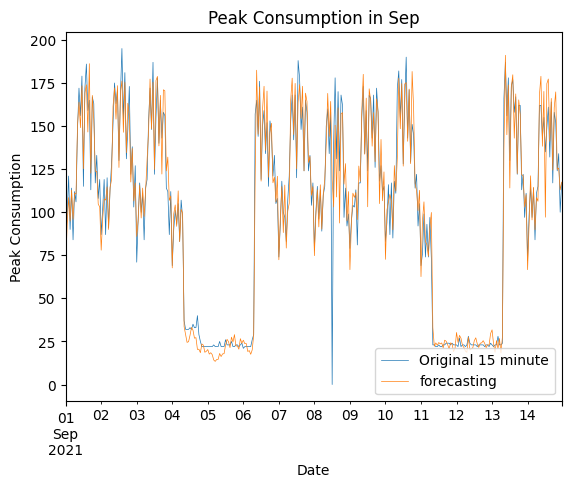

In [35]:
#실제값과 예측값 비교
compare_result.loc['2021-09'].plot(linewidth=0.5)
plt.title('Peak Consumption in Sep')
plt.ylabel('Peak Consumption')
plt.show()

In [36]:
#랜덤포레스트
import os
import sklearn

In [42]:
df_frame
#df_frame.head()
#df_frame.info()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


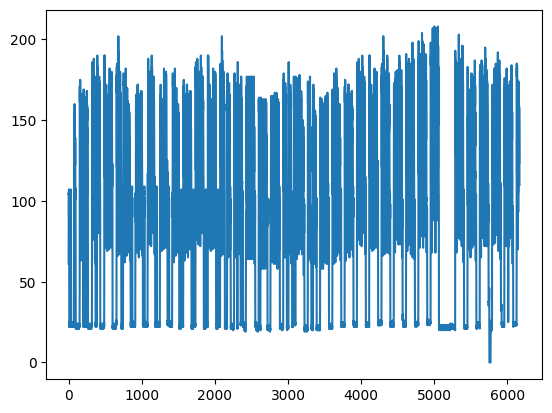

In [43]:
#시간당 평균 데이터 시각화
plt.plot(df_frame['평균'])

In [44]:
df_frame.drop(['평균', '날짜'], axis=1, inplace=True)
df_frame

,시간,15분,30분,45분,60분,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,0,62,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,1,96,93,116,113,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,2,106,96,106,107,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,3,92,110,110,109,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,4,108,105,106,108,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,19,152,151,171,139,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20,124,130,128,130,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,21,134,130,125,124,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,22,100,109,120,114,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


In [45]:
#결측치 비율 확인
for col in df_frame.columns:
    null_count = 'column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * (df_frame[col].isnull().sum() / df_frame[col].shape[0]))
    print(null_count)

column:         시간	 Percent of NaN value: 0.00%
column:        15분	 Percent of NaN value: 0.00%
column:        30분	 Percent of NaN value: 0.00%
column:        45분	 Percent of NaN value: 0.00%
column:        60분	 Percent of NaN value: 0.00%
column:        생산량	 Percent of NaN value: 0.00%
column:         기온	 Percent of NaN value: 0.00%
column:         풍속	 Percent of NaN value: 0.00%
column:         습도	 Percent of NaN value: 0.00%
column:        강수량	 Percent of NaN value: 0.00%
column:   전기요금(계절)	 Percent of NaN value: 0.00%
column:        day	 Percent of NaN value: 0.00%
column:          d	 Percent of NaN value: 0.00%
column:          m	 Percent of NaN value: 0.00%
column:       공장인원	 Percent of NaN value: 0.00%
column:        인건비	 Percent of NaN value: 0.00%


In [46]:
label_cat_names = ['15분','30분','45분','60분']
or_cat_rm_list = ["인건비","전기요금(계절)","공장인원","생산량"]
x_train = [] #입력값
cost_list = [] #비용관련값
for index in range(0,len(df_frame)):
    for col in label_cat_names: #15, 30, 45, 60분 각각 반복
        temp = list(df_frame.drop(or_cat_rm_list,axis=1).drop(label_cat_names,axis=1).iloc[0])
        #기본 정보만 남겨서 temp로
        temp.append(df_frame[col][index])
        cost_list.append(df_frame[or_cat_rm_list].iloc[index]) #최적화 단계에서 쓸 비용 관련 정보만
        x_train.append(temp)
y_labels = []
for index in range(0,len(df_frame)):
    for col in label_cat_names:
        y_labels.append(df_frame[col][index])
        #X: 그 시점의 조건들, Y: 그 시점에 실제로 관측된 값
        #pop(): X,Y,C의 개수 맞춤
        y_labels.pop(0)
x_train.pop(len(x_train)-1)
cost_list.pop(len(x_train)-1)
X = np.asarray(x_train)
C = np.asarray(cost_list)
y = np.asarray(y_labels)

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils.random import sample_without_replacement

In [48]:
#x 입력 y 정답 c 비용 정보
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)
c_train, c_test, cy_train, cy_test = train_test_split(C, y, test_size=0.3, random_state = 42)

In [49]:
#과적합 방지 위해 깊이 최대 20
forest_reg = RandomForestRegressor(max_depth=20, random_state=42)
forest_reg.fit(x_train, y_train)

RandomForestRegressor(max_depth=20, random_state=42)

In [50]:
#오차측정
mean_squared_error(forest_reg.predict(x_train), y_train)

185.9751419346689

In [51]:
mean_squared_error(forest_reg.predict(x_test), y_test)

183.06180686559583

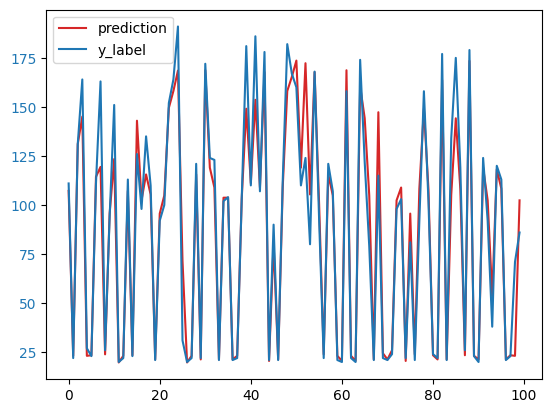

In [52]:
#무작위로 100개
prediction = forest_reg.predict(x_test)
predicted_sample_indexes = sample_without_replacement(len(prediction), 100)
color = 'tab:red'
plt.tick_params(axis='y', labelcolor=color)
plt.plot(prediction[predicted_sample_indexes], color=color)
color = 'tab:blue'
plt.plot(y_test[predicted_sample_indexes], color=color)
plt.tick_params(axis='y', labelcolor=color)
plt.legend(['prediction','y_label'])
plt.show()

In [53]:
#최적화
#total_elec_price: 예측된 전력 소비량과 전기 단가를 이용해 예상 전기요금을 계산
#total_human_cost: 생산량 등을 기준으로 예상 인건비를 계산
def build_objective_function_parameters(prediction, x_test, c_test, index=0):
    total_elec_price = prediction[index] * c_test[index][1] / 1000 + x_test[index][-1] * 1.1 - x_test[index][-2] * 1.1
    total_human_cost = c_test[index][2] * 50 - x_test[index][-1] * 1.1 + x_test[index][-2] * 1.1
    return total_elec_price, total_human_cost

In [54]:
from ortools.linear_solver import pywraplp

load C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\ortools\.libs\zlib1.dll...
load C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\ortools\.libs\abseil_dll.dll...
load C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\ortools\.libs\utf8_validity.dll...
load C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\ortools\.libs\re2.dll...
load C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\ortools\.libs\libprotobuf.dll...
load C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\ortools\.libs\highs.dll...
load C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\ortools\.libs\ortools.dll...


In [55]:
#x: 낮/밤 y: 투입 인원수
def objective_function(solver,c_test,cx,cy,x,y,index=0):
    objective = solver.Objective()
    if(c_test[index][0]==1) :
        objective.SetCoefficient(x, cx*2)
        objective.SetCoefficient(y, -cy)

    else:
        objective.SetCoefficient(x, cx//2)
        objective.SetCoefficient(y, -(cy)//2)
    objective.SetMinimization()
    return objective

In [56]:
def get_solution(pred,x_test,c_test,index = 118):
    solver = pywraplp.Solver.CreateSolver('GLOP')
    x = solver.NumVar(1, 2, 'x')
    y = solver.NumVar(1, 75, 'y')
    tep,thc = build_objective_function_parameters(pred,x_test,c_test,index)
    objective = objective_function(solver, c_test, tep, thc, x, y, index)
    objective = solver.Objective()
    constraint2 = solver.Constraint(11, 95)
    constraint2.SetCoefficient(x, 1)
    constraint2.SetCoefficient(y, 2)

    solver.Solve()

    opt_solution = tep * x.solution_value() - thc * y.solution_value()
    print("1이면 낮, 0이면 밤: ", x.solution_value())
    print("공장인원 수 : ", y.solution_value())
    print("final solution: ", opt_solution)
    if x.solution_value() == 1:
        print("생산량이 ",c_test[index][-2],"일 때, 낮에 공장직원 ", y.solution_value(),"을 투입 시켜야한다.")
    else :
        print("생산량이 ",c_test[index][-2],"일 때, 밤에 공장직원 ", y.solution_value(),"을 투입 시켜야한다.")

In [57]:
c_test[111][-2]

0.171837709

In [61]:
get_solution(prediction, x_test, c_test, 111)

1이면 낮, 0이면 밤:  1.0
공장인원 수 :  5.0
final solution:  610.4238440032458
생산량이  0.171837709 일 때, 낮에 공장직원  5.0 을 투입 시켜야한다.


In [ ]:
## 다중 기간 동시 최적화
# ▼ 랜덤포레스트 학습(forest_reg.fit) 및 x_test, c_test, prediction 생성까지 끝난 뒤에 이어서 실행
# from ortools.linear_solver import pywraplp
# import pandas as pd
# [2] 목적함수 파라미터 계산 함수 
# def build_objective_function_parameters(prediction, x_test, c_test, index=0):
#     total_elec_price = prediction[index] * c_test[index][1] / 1000 + x_test[index][-1]*1.1 - x_test[index][-2]*1.1
#     total_human_cost = c_test[index][2]*50 - x_test[index][-1]*1.1 + x_test[index][-2]*1.1
#     return total_elec_price, total_human_cost

In [75]:
import numpy as np
from sklearn.linear_model import LinearRegression

staff_actual = df_frame['공장인원'].values.reshape(-1, 1)
output_actual = df_frame['생산량'].values

mask = ~np.isnan(staff_actual.flatten()) & ~np.isnan(output_actual)
staff_actual = staff_actual[mask]
output_actual = output_actual[mask]

staff_reg = LinearRegression()
staff_reg.fit(staff_actual, output_actual)

a = staff_reg.coef_[0]
b = staff_reg.intercept_
print(f"생산량 = {a:.3f} * 공장인원 + {b:.3f}")
print("R²:", staff_reg.score(staff_actual, output_actual))


생산량 = 339.475 * 공장인원 + 162.207
R²: 0.6164060732786678


In [76]:
def estimate_required_staff(target_production, a, b, min_staff=1, max_staff=75):
    required = (target_production - b) / a
    return max(min_staff, min(max_staff, int(np.ceil(required))))

In [77]:
print(c_test[0])   # [인건비, 전기요금(계절), 공장인원, 생산량] 순서인지 확인

[1.00000000e+00 1.67200000e+02 3.56394453e+00 2.31300000e+03]


In [78]:
def get_solution_multi_period(pred, x_test, c_test, start_index=0, n_periods=24, a=None, b=None,
                                budget_total=None, max_delta=10, elec_price_ref=1.0):
    solver = pywraplp.Solver.CreateSolver('CBC')

    y = [solver.IntVar(1, 75, f'y_{t}') for t in range(n_periods)]

    objective = solver.Objective()
    required_list = []
    for t in range(n_periods):
        idx = start_index + t

        wage_multiplier = c_test[idx][0]     # 1.0(주간) 또는 1.5(야간) — 실제 관측값, 고정 상수로 사용
        target_production = c_test[idx][3]   # 그 시점 실제(목표) 생산량

        required_staff = estimate_required_staff(target_production, a, b)
        required_list.append(required_staff)

        # 인건비: 인원수 × 시급 × (낮/밤 배수)
        labor_cost_per_person = 50 * wage_multiplier
        objective.SetCoefficient(y[t], labor_cost_per_person)   # 비용이므로 항상 양수 → 최소화 자연스럽게 작동

    objective.SetMinimization()

    # 제약1: 예측/실제 생산에 필요한 최소 인원 보장
    for t in range(n_periods):
        solver.Add(y[t] >= required_list[t])

    # 제약2: 인접 시간대 간 급격한 인원 변화 방지
    for t in range(1, n_periods):
        solver.Add(y[t] - y[t-1] <= max_delta)
        solver.Add(y[t-1] - y[t] <= max_delta)

    # 제약3: (선택) 하루 전체 누적 인원 예산 제한
    if budget_total is not None:
        solver.Add(solver.Sum(y) <= budget_total)

    solver.Solve()

    results = [{'t': t, '필요최소인원': required_list[t], '배치인원': y[t].solution_value()}
               for t in range(n_periods)]
    return pd.DataFrame(results)


In [79]:
result_df = get_solution_multi_period(prediction, x_test, c_test, start_index=111, n_periods=24,
                                       a=a, b=b, budget_total=None, max_delta=10)
result_df

,t,필요최소인원,배치인원
0,0,1,1.0
1,1,1,1.0
2,2,1,1.0
3,3,1,1.0
4,4,1,1.0
5,5,1,1.0
6,6,6,6.0
7,7,8,8.0
8,8,1,1.0
9,9,1,1.0


In [80]:
for t in range(24):
    idx = 111 + t
    target = c_test[idx][3]
    raw_required = (target - b) / a   # 하한 적용 전 순수 계산값
    print(t, "목표생산량:", target, "역산인원(하한적용전):", raw_required)


0 목표생산량: 72.0 역산인원(하한적용전): -0.2657251881606089
1 목표생산량: 0.0 역산인원(하한적용전): -0.47781736113122664
2 목표생산량: 0.0 역산인원(하한적용전): -0.47781736113122664
3 목표생산량: 351.0 역산인원(하한적용전): 0.5561319821005349
4 목표생산량: 0.0 역산인원(하한적용전): -0.47781736113122664
5 목표생산량: 8.0 역산인원(하한적용전): -0.45425156413449136
6 목표생산량: 2120.0 역산인원(하한적용전): 5.7671188430036295
7 목표생산량: 2776.0 역산인원(하한적용전): 7.699514196735925
8 목표생산량: 0.0 역산인원(하한적용전): -0.47781736113122664
9 목표생산량: 0.0 역산인원(하한적용전): -0.47781736113122664
10 목표생산량: 1195.0 역산인원(하한적용전): 3.0423235652561096
11 목표생산량: 0.0 역산인원(하한적용전): -0.47781736113122664
12 목표생산량: 0.0 역산인원(하한적용전): -0.47781736113122664
13 목표생산량: 0.0 역산인원(하한적용전): -0.47781736113122664
14 목표생산량: 48.0 역산인원(하한적용전): -0.3364225791508148
15 목표생산량: 0.0 역산인원(하한적용전): -0.47781736113122664
16 목표생산량: 81.0 역산인원(하한적용전): -0.2392136665392817
17 목표생산량: 37.0 역산인원(하한적용전): -0.3688255500213259
18 목표생산량: 2151.0 역산인원(하한적용전): 5.858436306365979
19 목표생산량: 376.0 역산인원(하한적용전): 0.6297750977153327
20 목표생산량: 12.0 역산인원(하한적용전): -0.4424686656361237
